In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [1]:
from google.colab import files

uploaded = files.upload()

Saving Cleaned_ApexPlanet_Sales_Dataset.xlsx to Cleaned_ApexPlanet_Sales_Dataset.xlsx


In [3]:
df = pd.read_excel("Cleaned_ApexPlanet_Sales_Dataset.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000, 15)


In [4]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Year,Month,Month_Name
0,ORD100002,2025-02-25,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,February
1,ORD100003,2025-10-14,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,October
2,ORD100004,2025-05-13,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,May
3,ORD100005,2025-12-02,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,December
4,ORD100006,2025-11-20,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,November


In [5]:
print("Columns:")
for col in df.columns:
    print("-", col)

Columns:
- Order_ID
- Order_Date
- Customer_ID
- Customer_Name
- Age
- Gender
- City
- Product
- Category
- Quantity
- Unit_Price
- Total_Sales
- Year
- Month
- Month_Name


In [6]:
print("DATASET INFORMATION")
print("=" * 50)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1000 non-null   object        
 1   Order_Date     1000 non-null   datetime64[ns]
 2   Customer_ID    1000 non-null   object        
 3   Customer_Name  1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   Gender         1000 non-null   object        
 6   City           1000 non-null   object        
 7   Product        1000 non-null   object        
 8   Category       1000 non-null   object        
 9   Quantity       1000 non-null   int64         
 10  Unit_Price     1000 non-null   float64       
 11  Total_Sales    1000 non-null   float64       
 12  Year           1000 non-null   int64         
 13  Month          1000 non-null   int64         
 14  Month_Name     1000 non-null   object        
dtypes:

In [7]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(list(numerical_columns))

Numerical Columns:
['Age', 'Quantity', 'Unit_Price', 'Total_Sales', 'Year', 'Month']


In [8]:
print("NUMERICAL SUMMARY STATISTICS")
print("=" * 50)

df[numerical_columns].describe().round(2)

NUMERICAL SUMMARY STATISTICS


,Age,Quantity,Unit_Price,Total_Sales,Year,Month
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,41.35,5.44,25486.78,139399.44,2025.00,6.52
std,13.68,2.84,14179.40,114100.05,0.07,3.50
min,18.00,1.00,145.78,437.34,2025.00,1.00
25%,30.00,3.00,13895.72,47066.63,2025.00,3.00
50%,41.00,5.00,25398.74,108594.02,2025.00,6.00
75%,53.00,8.00,37512.38,203722.88,2025.00,10.00
max,65.00,10.00,49997.53,493677.50,2026.00,12.00


In [9]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
['Order_ID', 'Customer_ID', 'Customer_Name', 'Gender', 'City', 'Product', 'Category', 'Month_Name']


In [10]:
print("GENDER DISTRIBUTION")
print("=" * 50)

print(df["Gender"].value_counts())

GENDER DISTRIBUTION
Gender
Male      511
Female    489
Name: count, dtype: int64


In [11]:
gender_percentage = (
    df["Gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(gender_percentage)

Gender
Male      51.1
Female    48.9
Name: proportion, dtype: float64


In [12]:
print("CATEGORY DISTRIBUTION")
print("=" * 50)

print(df["Category"].value_counts())

CATEGORY DISTRIBUTION
Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64


In [13]:
category_percentage = (
    df["Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(category_percentage)

Category
Electronics    35.4
Education      17.8
Furniture      15.9
Fashion        15.6
Grocery        15.3
Name: proportion, dtype: float64


In [14]:
print("TOP 10 CITIES BY NUMBER OF ORDERS")
print("=" * 50)

print(df["City"].value_counts().head(10))

TOP 10 CITIES BY NUMBER OF ORDERS
City
Patna        135
Kolkata      133
Mumbai       131
Delhi        125
Hyderabad    125
Bengaluru    122
Gaya         117
Pune          99
Unknown       13
Name: count, dtype: int64


In [15]:
print("TOP 10 PRODUCTS BY NUMBER OF ORDERS")
print("=" * 50)

print(df["Product"].value_counts().head(10))

TOP 10 PRODUCTS BY NUMBER OF ORDERS
Product
Mobile    184
Book      178
Laptop    170
Chair     159
Shoes     156
Rice      153
Name: count, dtype: int64


In [16]:
import os

os.makedirs("EDA_Charts", exist_ok=True)

print("EDA_Charts folder created successfully!")

EDA_Charts folder created successfully!


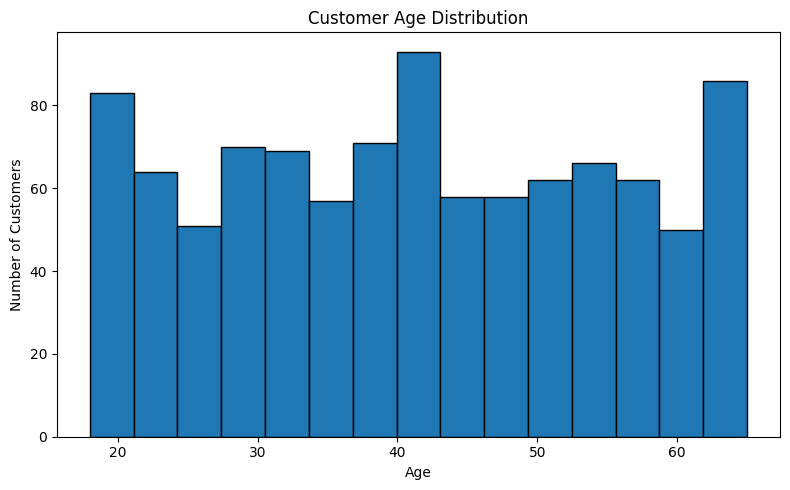

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(df["Age"], bins=15, edgecolor="black")

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("EDA_Charts/age_distribution.png", dpi=300)
plt.show()

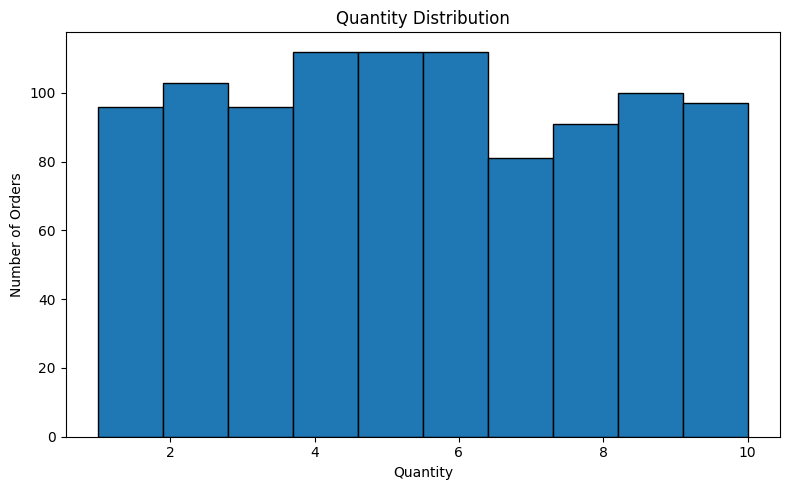

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(df["Quantity"], bins=10, edgecolor="black")

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.savefig("EDA_Charts/quantity_distribution.png", dpi=300)
plt.show()

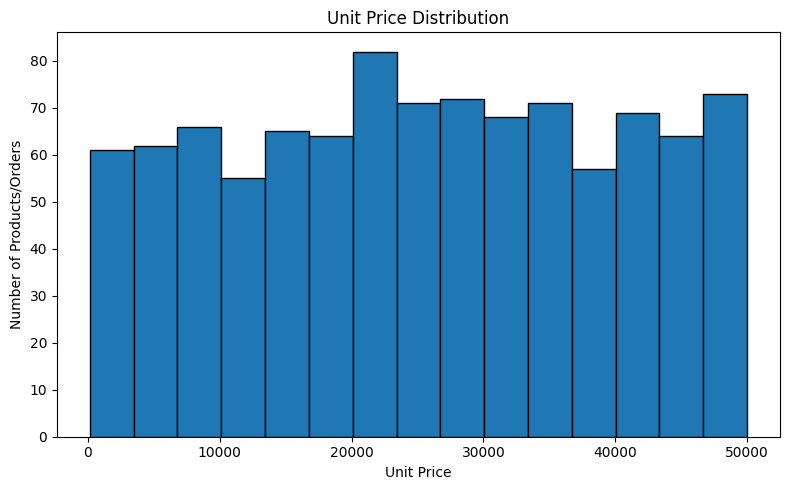

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(df["Unit_Price"], bins=15, edgecolor="black")

plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Number of Products/Orders")

plt.tight_layout()
plt.savefig("EDA_Charts/unit_price_distribution.png", dpi=300)
plt.show()

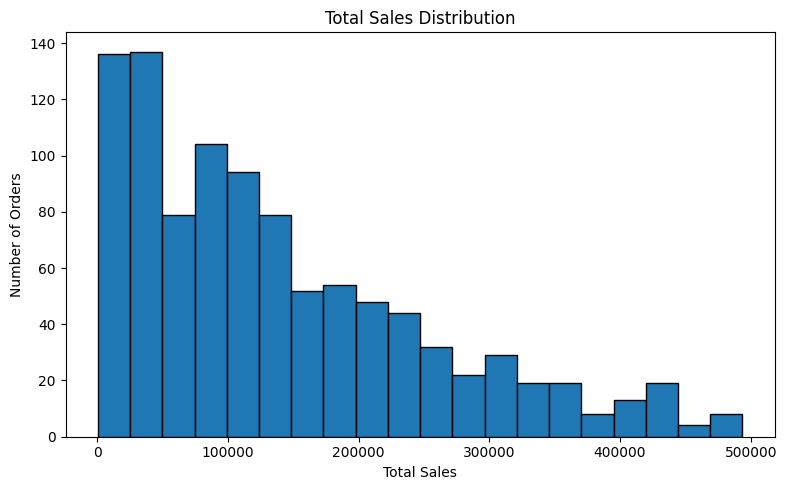

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(df["Total_Sales"], bins=20, edgecolor="black")

plt.title("Total Sales Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.savefig("EDA_Charts/total_sales_distribution.png", dpi=300)
plt.show()

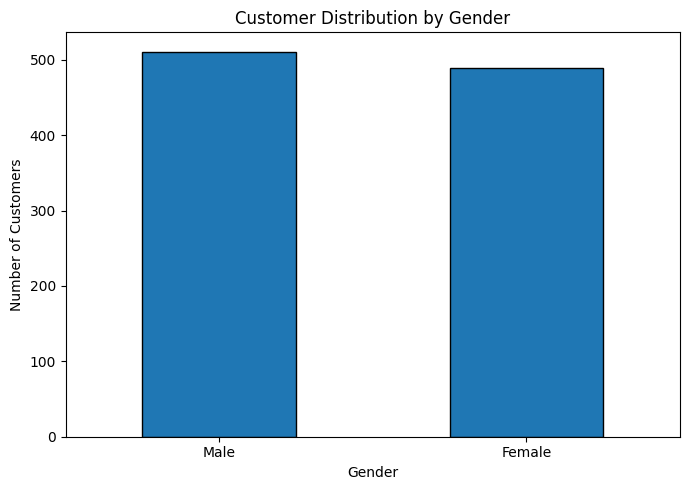

In [21]:
plt.figure(figsize=(7, 5))

df["Gender"].value_counts().plot(kind="bar", edgecolor="black")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("EDA_Charts/gender_distribution.png", dpi=300)
plt.show()

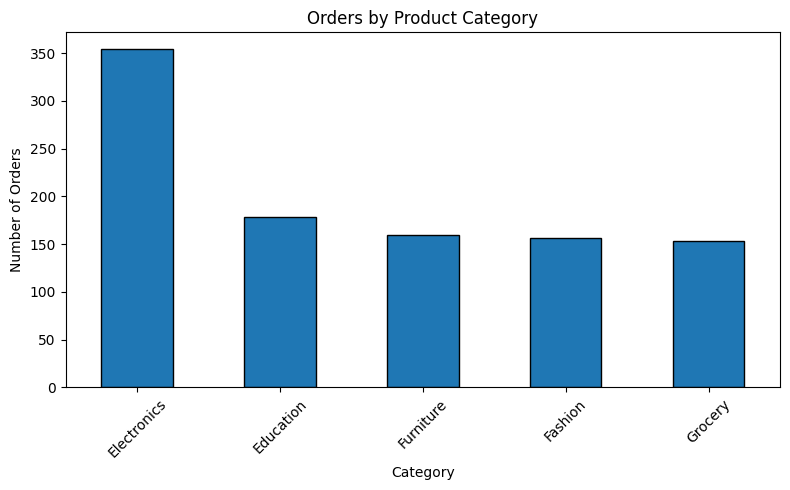

In [22]:
plt.figure(figsize=(8, 5))

df["Category"].value_counts().plot(kind="bar", edgecolor="black")

plt.title("Orders by Product Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("EDA_Charts/category_distribution.png", dpi=300)
plt.show()

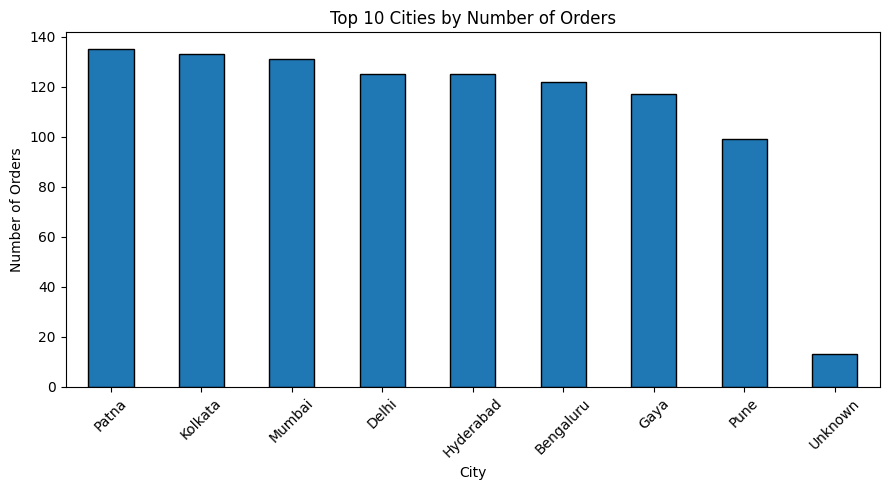

In [23]:
top_cities = df["City"].value_counts().head(10)

plt.figure(figsize=(9, 5))

top_cities.plot(kind="bar", edgecolor="black")

plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("EDA_Charts/top_10_cities.png", dpi=300)
plt.show()

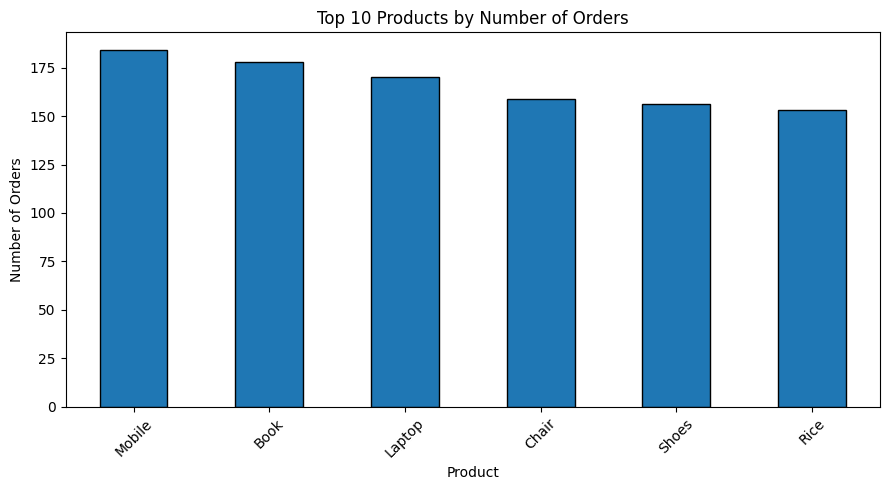

In [24]:
top_products = df["Product"].value_counts().head(10)

plt.figure(figsize=(9, 5))

top_products.plot(kind="bar", edgecolor="black")

plt.title("Top 10 Products by Number of Orders")
plt.xlabel("Product")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("EDA_Charts/top_10_products.png", dpi=300)
plt.show()

In [25]:
total_revenue = df["Total_Sales"].sum()
average_order_value = df["Total_Sales"].mean()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_ID"].nunique()
total_units = df["Quantity"].sum()

print("KEY BUSINESS METRICS")
print("=" * 50)
print(f"Total Revenue       : {total_revenue:,.2f}")
print(f"Average Order Value : {average_order_value:,.2f}")
print(f"Total Orders        : {total_orders:,}")
print(f"Unique Customers    : {total_customers:,}")
print(f"Total Units Sold    : {total_units:,}")

KEY BUSINESS METRICS
Total Revenue       : 139,399,439.65
Average Order Value : 139,399.44
Total Orders        : 992
Unique Customers    : 947
Total Units Sold    : 5,435


In [26]:
category_sales = (
    df.groupby("Category")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("SALES BY CATEGORY")
print("=" * 50)
print(category_sales.round(2))

print("\nTop Revenue Category:")
print(category_sales.index[0])
print(f"Revenue: {category_sales.iloc[0]:,.2f}")

SALES BY CATEGORY
Category
Electronics    50778581.70
Education      25031689.40
Grocery        22231711.28
Furniture      21521561.48
Fashion        19835895.79
Name: Total_Sales, dtype: float64

Top Revenue Category:
Electronics
Revenue: 50,778,581.70


In [27]:
product_sales = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("TOP 10 PRODUCTS BY REVENUE")
print("=" * 50)
print(product_sales.head(10).round(2))

TOP 10 PRODUCTS BY REVENUE
Product
Laptop    25443008.51
Mobile    25335573.19
Book      25031689.40
Rice      22231711.28
Chair     21521561.48
Shoes     19835895.79
Name: Total_Sales, dtype: float64


In [28]:
gender_sales = (
    df.groupby("Gender")["Total_Sales"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

gender_sales.columns = ["Total_Sales", "Average_Sales", "Order_Count"]

print("SALES BY GENDER")
print("=" * 50)
print(gender_sales.round(2))

SALES BY GENDER
        Total_Sales  Average_Sales  Order_Count
Gender                                         
Male    72463550.63      141807.34          511
Female  66935889.02      136883.21          489


In [29]:
monthly_sales = (
    df.groupby(["Year", "Month", "Month_Name"])["Total_Sales"]
    .sum()
    .reset_index()
    .sort_values(["Year", "Month"])
)

print("MONTHLY SALES")
print("=" * 50)
print(monthly_sales.round(2))

MONTHLY SALES
    Year  Month Month_Name  Total_Sales
0   2025      1    January  10096190.73
1   2025      2   February  11511181.46
2   2025      3      March  13059899.94
3   2025      4      April  12222700.17
4   2025      5        May  10984689.25
5   2025      6       June  12912332.64
6   2025      7       July  11746226.80
7   2025      8     August   9448471.22
8   2025      9  September   9179896.29
9   2025     10    October  12500936.50
10  2025     11   November  12627620.22
11  2025     12   December  12299904.44
12  2026      1    January    809389.99


In [30]:
highest_month = monthly_sales.loc[
    monthly_sales["Total_Sales"].idxmax()
]

print("HIGHEST SALES MONTH")
print("=" * 50)
print(
    f"{highest_month['Month_Name']} {int(highest_month['Year'])}"
    f" → {highest_month['Total_Sales']:,.2f}"
)


HIGHEST SALES MONTH
March 2025 → 13,059,899.94


In [31]:
top_category = category_sales.index[0]
top_category_sales = category_sales.iloc[0]

top_product = product_sales.index[0]
top_product_sales = product_sales.iloc[0]

top_gender = gender_sales["Total_Sales"].idxmax()

print("KEY EDA INSIGHTS")
print("=" * 50)

print(f"1. The highest revenue-generating category is {top_category}, "
      f"with total sales of {top_category_sales:,.2f}.")

print(f"2. The highest revenue-generating product is {top_product}, "
      f"with total sales of {top_product_sales:,.2f}.")

print(f"3. The gender segment generating the highest total sales is {top_gender}.")

print(f"4. The average order value is {average_order_value:,.2f}.")

print(f"5. The dataset contains {total_orders:,} orders "
      f"from {total_customers:,} unique customers.")

print(f"6. Total units sold across all orders are {total_units:,}.")

KEY EDA INSIGHTS
1. The highest revenue-generating category is Electronics, with total sales of 50,778,581.70.
2. The highest revenue-generating product is Laptop, with total sales of 25,443,008.51.
3. The gender segment generating the highest total sales is Male.
4. The average order value is 139,399.44.
5. The dataset contains 992 orders from 947 unique customers.
6. Total units sold across all orders are 5,435.


In [32]:
import sqlite3

# Create SQLite database in memory
conn = sqlite3.connect(":memory:")

# Load Pandas DataFrame into SQL table
df.to_sql("sales", conn, index=False, if_exists="replace")

print("SQL database created successfully!")
print("Table name: sales")

SQL database created successfully!
Table name: sales


In [33]:
query = """
SELECT *
FROM sales
LIMIT 5;
"""

sql_preview = pd.read_sql_query(query, conn)

sql_preview

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Year,Month,Month_Name
0,ORD100002,2025-02-25 00:00:00,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,February
1,ORD100003,2025-10-14 00:00:00,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,October
2,ORD100004,2025-05-13 00:00:00,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,May
3,ORD100005,2025-12-02 00:00:00,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,December
4,ORD100006,2025-11-20 00:00:00,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,November


In [34]:
query = """
PRAGMA table_info(sales);
"""

pd.read_sql_query(query, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Order_ID,TEXT,0,None,0
1,1,Order_Date,TIMESTAMP,0,None,0
2,2,Customer_ID,TEXT,0,None,0
3,3,Customer_Name,TEXT,0,None,0
4,4,Age,INTEGER,0,None,0
5,5,Gender,TEXT,0,None,0
6,6,City,TEXT,0,None,0
7,7,Product,TEXT,0,None,0
8,8,Category,TEXT,0,None,0
9,9,Quantity,INTEGER,0,None,0


In [35]:
# Create customer dimension table for JOIN analysis
customers = df[
    ["Customer_ID", "Customer_Name", "Gender", "Age", "City"]
].drop_duplicates("Customer_ID")

customers.to_sql("customers", conn, index=False, if_exists="replace")

print("Customers table created successfully!")

Customers table created successfully!


In [36]:
query = """
SELECT *
FROM customers
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Customer_ID,Customer_Name,Gender,Age,City
0,CUST5529,Customer_227,Female,30,Bengaluru
1,CUST3127,Customer_182,Male,63,Bengaluru
2,CUST8887,Customer_487,Female,62,Bengaluru
3,CUST2515,Customer_470,Female,65,Kolkata
4,CUST4796,Customer_380,Male,44,Bengaluru


What is the total sales revenue generated from all orders?

In [37]:
query1 = """
SELECT
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales;
"""

result1 = pd.read_sql_query(query1, conn)
result1

,Total_Revenue
0,1.393994e+08


Which product category generates the highest total revenue?

In [38]:
query2 = """
SELECT
    Category,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue,
    SUM(Quantity) AS Total_Units_Sold
FROM sales
GROUP BY Category
ORDER BY Total_Revenue DESC;
"""

result2 = pd.read_sql_query(query2, conn)
result2

,Category,Total_Revenue,Total_Units_Sold
0,Electronics,50778581.70,1978
1,Education,25031689.40,977
2,Grocery,22231711.28,826
3,Furniture,21521561.48,855
4,Fashion,19835895.79,799


Which products are generating the highest revenue?

In [39]:
query3 = """
SELECT
    Product,
    Category,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue,
    SUM(Quantity) AS Total_Units_Sold
FROM sales
GROUP BY Product, Category
ORDER BY Total_Revenue DESC
LIMIT 10;
"""

result3 = pd.read_sql_query(query3, conn)
result3

,Product,Category,Total_Revenue,Total_Units_Sold
0,Laptop,Electronics,25443008.51,970
1,Mobile,Electronics,25335573.19,1008
2,Book,Education,25031689.40,977
3,Rice,Grocery,22231711.28,826
4,Chair,Furniture,21521561.48,855
5,Shoes,Fashion,19835895.79,799


How does total sales revenue change month by month?

In [40]:
query4 = """
SELECT
    Year,
    Month,
    Month_Name,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue,
    SUM(Quantity) AS Total_Units_Sold
FROM sales
GROUP BY Year, Month, Month_Name
ORDER BY Year, Month;
"""

result4 = pd.read_sql_query(query4, conn)
result4

,Year,Month,Month_Name,Total_Revenue,Total_Units_Sold
0,2025,1,January,10096190.73,376
1,2025,2,February,11511181.46,444
2,2025,3,March,13059899.94,467
3,2025,4,April,12222700.17,482
4,2025,5,May,10984689.25,424
5,2025,6,June,12912332.64,477
6,2025,7,July,11746226.80,466
7,2025,8,August,9448471.22,391
8,2025,9,September,9179896.29,406
9,2025,10,October,12500936.50,485


Which customers generate the highest total revenue?

In [41]:
query5 = """
SELECT
    c.Customer_ID,
    c.Customer_Name,
    c.City,
    ROUND(SUM(s.Total_Sales), 2) AS Total_Revenue,
    SUM(s.Quantity) AS Total_Units_Sold
FROM sales s
JOIN customers c
    ON s.Customer_ID = c.Customer_ID
GROUP BY
    c.Customer_ID,
    c.Customer_Name,
    c.City
ORDER BY Total_Revenue DESC
LIMIT 10;
"""

result5 = pd.read_sql_query(query5, conn)
result5

,Customer_ID,Customer_Name,City,Total_Revenue,Total_Units_Sold
0,CUST9510,Customer_345,Kolkata,867333.24,19
1,CUST6845,Customer_337,Hyderabad,769479.75,18
2,CUST6532,Customer_348,Pune,610981.74,15
3,CUST6082,Customer_301,Mumbai,548416.39,16
4,CUST3689,Customer_179,Delhi,542484.08,16
5,CUST3730,Customer_273,Unknown,538633.97,13
6,CUST4706,Customer_34,Delhi,528036.44,11
7,CUST9693,Customer_343,Patna,511421.86,13
8,CUST7374,Customer_375,Patna,511309.40,15
9,CUST2062,Customer_254,Patna,493677.50,10


In [47]:
output_file = "SQL_Query_Results.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    result1.to_excel(writer, sheet_name="Q1_Total_Revenue", index=False)
    result2.to_excel(writer, sheet_name="Q2_Category_Revenue", index=False)
    result3.to_excel(writer, sheet_name="Q3_Top_Products", index=False)
    result4.to_excel(writer, sheet_name="Q4_Monthly_Sales", index=False)
    result5.to_excel(writer, sheet_name="Q5_Top_Customers", index=False)

print("Excel file created successfully!")

Excel file created successfully!


In [48]:
from google.colab import files
files.download("SQL_Query_Results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
print("result1:", result1.shape)
print("result2:", result2.shape)
print("result3:", result3.shape)
print("result4:", result4.shape)
print("result5:", result5.shape)

result1: (1, 1)
result2: (5, 3)
result3: (6, 4)
result4: (13, 5)
result5: (10, 5)


In [45]:
sql_content = """
-- ApexPlanet Task 2: SQL Business Questions
-- Dataset: Cleaned ApexPlanet Sales Dataset

-- Q1. What is the total sales revenue generated from all orders?
SELECT
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales;


-- Q2. Which product category generates the highest total revenue?
SELECT
    Category,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue,
    SUM(Quantity) AS Total_Units_Sold
FROM sales
GROUP BY Category
ORDER BY Total_Revenue DESC;


-- Q3. Which products are generating the highest revenue?
SELECT
    Product,
    Category,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue,
    SUM(Quantity) AS Total_Units_Sold
FROM sales
GROUP BY Product, Category
ORDER BY Total_Revenue DESC
LIMIT 10;


-- Q4. How does total sales revenue change month by month?
SELECT
    Year,
    Month,
    Month_Name,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue,
    SUM(Quantity) AS Total_Units_Sold
FROM sales
GROUP BY Year, Month, Month_Name
ORDER BY Year, Month;


-- Q5. Which customers generate the highest total revenue?
-- JOIN between sales and customers tables
SELECT
    c.Customer_ID,
    c.Customer_Name,
    c.City,
    ROUND(SUM(s.Total_Sales), 2) AS Total_Revenue,
    SUM(s.Quantity) AS Total_Units_Sold
FROM sales s
JOIN customers c
    ON s.Customer_ID = c.Customer_ID
GROUP BY
    c.Customer_ID,
    c.Customer_Name,
    c.City
ORDER BY Total_Revenue DESC
LIMIT 10;
"""

with open("SQL_Business_Questions.sql", "w") as file:
    file.write(sql_content)

print("SQL_Business_Questions.sql created successfully!")

SQL_Business_Questions.sql created successfully!


In [46]:
from google.colab import files

files.download("SQL_Business_Questions.sql")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
import shutil

shutil.make_archive("EDA_Charts", "zip", "EDA_Charts")

print("EDA_Charts.zip created successfully!")

EDA_Charts.zip created successfully!


In [51]:
from google.colab import files

files.download("EDA_Charts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
correlation_matrix = df[
    ["Age", "Quantity", "Unit_Price", "Total_Sales"]
].corr().round(2)

correlation_matrix

,Age,Quantity,Unit_Price,Total_Sales
Age,1.00,-0.03,-0.01,0.00
Quantity,-0.03,1.00,0.02,0.65
Unit_Price,-0.01,0.02,1.00,0.69
Total_Sales,0.00,0.65,0.69,1.00


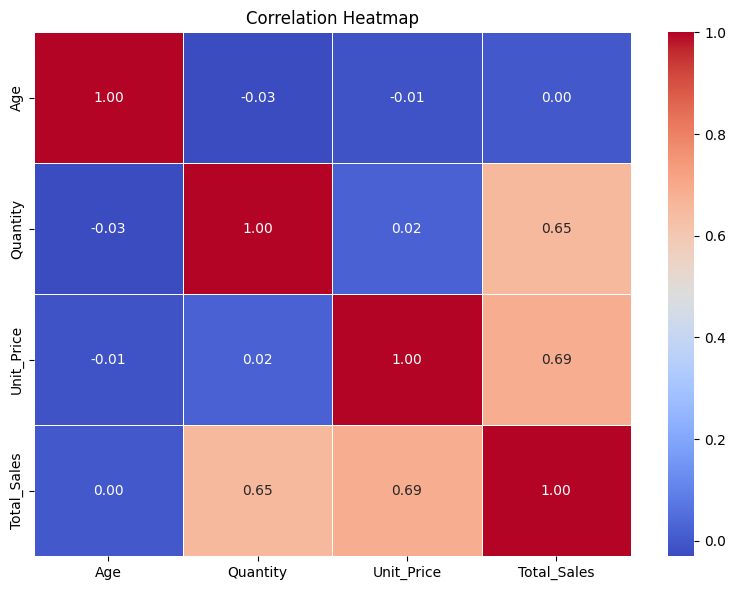

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    "EDA_Charts/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

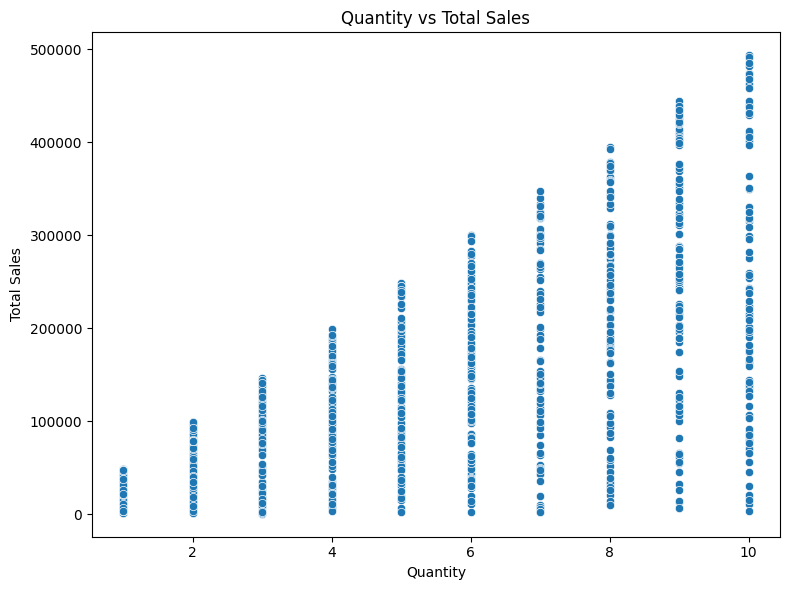

In [54]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total_Sales"
)

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    "EDA_Charts/quantity_vs_total_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
plt.savefig(
    "EDA_Charts/quantity_vs_total_sales.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [56]:
import shutil

shutil.make_archive("EDA_Charts", "zip", "EDA_Charts")

print("EDA_Charts.zip updated successfully!")

EDA_Charts.zip updated successfully!


In [60]:
from google.colab import files

files.download("EDA_Charts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
print(df[["Quantity", "Total_Sales"]].head(10))
print("\nMissing values:")
print(df[["Quantity", "Total_Sales"]].isnull().sum())
print("\nData types:")
print(df[["Quantity", "Total_Sales"]].dtypes)

   Quantity  Total_Sales
0         7     19808.39
1         5    139530.80
2         8    299928.48
3         9    256872.24
4        10    140365.90
5         9    323527.23
6         6    299985.18
7         3     28466.49
8         6    116929.38
9         8    144194.72

Missing values:
Quantity       0
Total_Sales    0
dtype: int64

Data types:
Quantity         int64
Total_Sales    float64
dtype: object


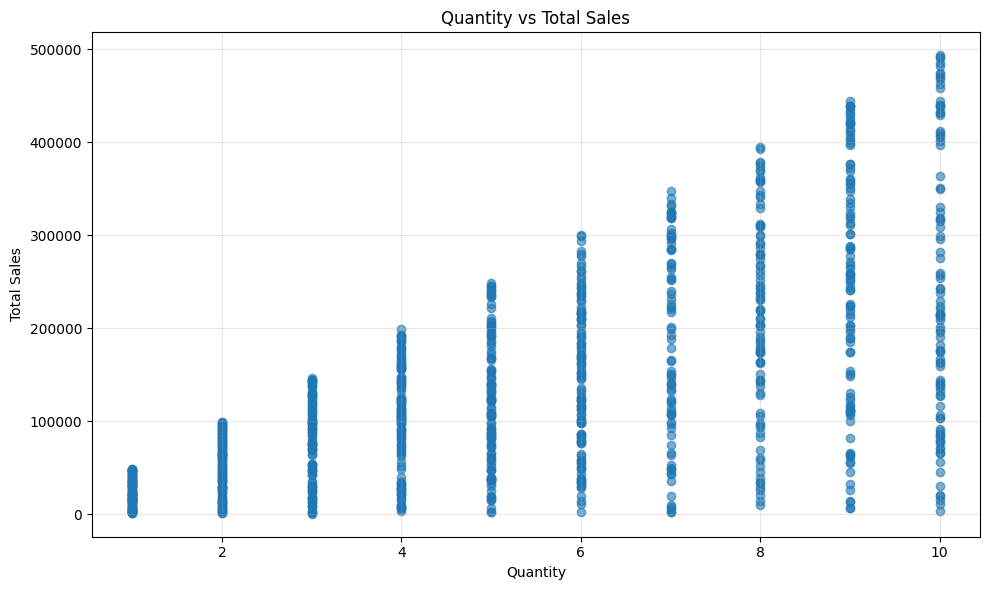

✅ quantity_vs_total_sales.png saved successfully!


In [62]:
import matplotlib.pyplot as plt
import os

# Make sure folder exists
os.makedirs("EDA_Charts", exist_ok=True)

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Quantity"],
    df["Total_Sales"],
    alpha=0.6
)

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save chart
plt.savefig(
    "EDA_Charts/quantity_vs_total_sales.png",
    dpi=300,
    bbox_inches="tight"
)

# Display chart
plt.show()

print("✅ quantity_vs_total_sales.png saved successfully!")

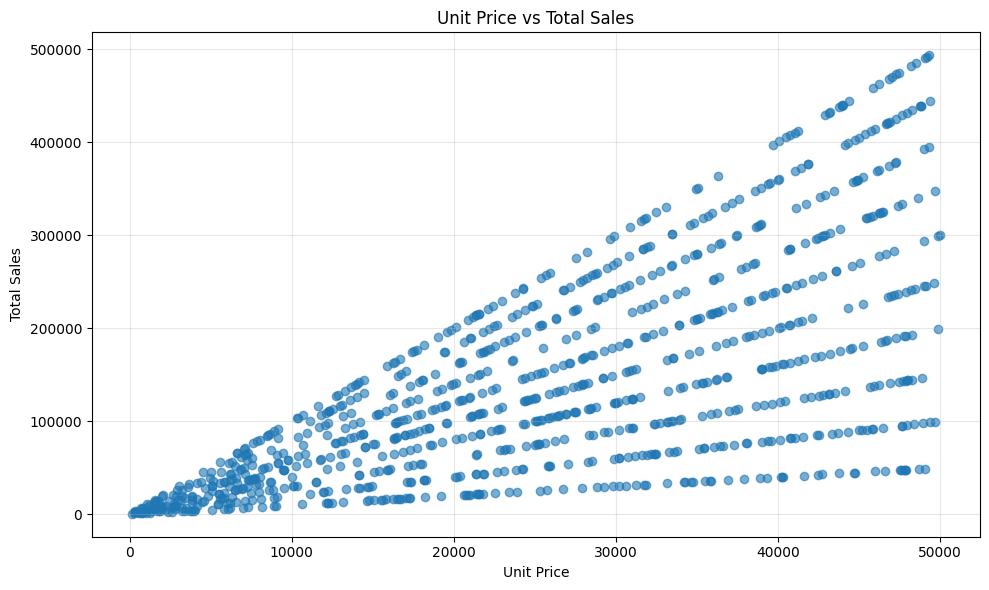

✅ unit_price_vs_total_sales.png saved successfully!


In [63]:
import matplotlib.pyplot as plt
import os

os.makedirs("EDA_Charts", exist_ok=True)

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Unit_Price"],
    df["Total_Sales"],
    alpha=0.6
)

plt.title("Unit Price vs Total Sales")
plt.xlabel("Unit Price")
plt.ylabel("Total Sales")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "EDA_Charts/unit_price_vs_total_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ unit_price_vs_total_sales.png saved successfully!")

In [64]:
import os

print(os.listdir("EDA_Charts"))

['age_distribution.png', 'top_10_products.png', 'correlation_heatmap.png', 'gender_distribution.png', 'top_10_cities.png', 'quantity_distribution.png', 'quantity_vs_total_sales.png', 'unit_price_vs_total_sales.png', 'unit_price_distribution.png', 'total_sales_distribution.png', 'category_distribution.png']


In [65]:
import shutil

shutil.make_archive("EDA_Charts", "zip", "EDA_Charts")

print("✅ EDA_Charts.zip updated successfully!")

✅ EDA_Charts.zip updated successfully!


In [66]:
from google.colab import files

files.download("EDA_Charts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
# Display correlation values
print("Correlation Matrix:")
display(correlation_matrix)

# Find the strongest relationship between different variables
corr_pairs = correlation_matrix.where(
    ~np.eye(correlation_matrix.shape[0], dtype=bool)
).stack()

strongest_pair = corr_pairs.abs().idxmax()
strongest_value = corr_pairs.loc[strongest_pair]

print("\nStrongest Relationship:")
print(f"{strongest_pair[0]} vs {strongest_pair[1]} = {strongest_value:.2f}")

# Business interpretation
if abs(strongest_value) >= 0.7:
    strength = "strong"
elif abs(strongest_value) >= 0.4:
    strength = "moderate"
else:
    strength = "weak"

direction = "positive" if strongest_value > 0 else "negative"

print(
    f"\nBusiness Insight: {strongest_pair[0]} and {strongest_pair[1]} "
    f"have a {strength} {direction} relationship "
    f"(correlation = {strongest_value:.2f})."
)

Correlation Matrix:


,Age,Quantity,Unit_Price,Total_Sales
Age,1.00,-0.03,-0.01,0.00
Quantity,-0.03,1.00,0.02,0.65
Unit_Price,-0.01,0.02,1.00,0.69
Total_Sales,0.00,0.65,0.69,1.00



Strongest Relationship:
Unit_Price vs Total_Sales = 0.69

Business Insight: Unit_Price and Total_Sales have a moderate positive relationship (correlation = 0.69).
